# SNN Preprocessing + Hyperparameter Tuning

Tunes both preprocessing parameters (keypoint detection, grid binning, distance/aruco encoding)
and SNN hyperparameters jointly over raw training runs from the `Trening/` directory.

**Input structure per run:**
- `data.csv`: timestamp, image_filename, range_center_m, aruco_x_norm, cmd_linear_x, cmd_angular_z
- `images/`: grayscale PNG frames

**Strategy:** Keypoint detection is cached per (frame, FAST threshold) since it is the bottleneck.
All cheaper operations (binning, encoding, label mapping) run inside the tuning loop.

In [5]:
import cv2 as cv
import numpy as np
import pandas as pd
import itertools
import math
import sys
from pathlib import Path
from tqdm import tqdm

sys.path.insert(0, str(Path(".").resolve()))
from LIF_SNN_network import SNNLayer

np.random.seed(42)

## Paths & constants

In [6]:
TRENING_DIR = Path("../Trening")
RESULTS_DIR = Path("CSV_results")

FRAME_WIDTH  = 640
FRAME_HEIGHT = 480

# SNN output size (left / forward / right)
N_OUTPUTS = 3

## Preprocessing parameter ranges

| Parameter | Effect |
|---|---|
| `fast_threshold` | Detector sensitivity — higher = fewer, stronger corners |
| `response_cutoff` | Drop keypoints with FAST response below this value |
| `max_keypoints` | Cap on keypoints per frame (highest-response kept) |
| `n_bins_x / n_bins_y` | Grid resolution: columns × rows |
| `n_threshold_levels` | Number of count intervals for event-driven encoding |
| `threshold_max` | Upper bound of count range for interval edges |
| `n_dist_bits` | Thermometric distance bits — 1 = binary, >1 = closer → more spikes |
| `dist_max_m` | Max sensing range; thresholds spaced evenly from `dist_max_m` down to `dist_max_m / n_dist_bits` |
| `n_aruco_bins` | Lateral zones for aruco x-position encoding |
| `angular_dead_zone` | \|angular_z\| below this → classified as forward |

**Thermometric encoding example** with `n_dist_bits=4`, `dist_max_m=2.0`
(thresholds: 2.0 m, 1.5 m, 1.0 m, 0.5 m):

| Range | Spikes |
|---|---|
| > 2.0 m | `[0, 0, 0, 0]` |
| 1.5 – 2.0 m | `[1, 0, 0, 0]` |
| 1.0 – 1.5 m | `[1, 1, 0, 0]` |
| 0.5 – 1.0 m | `[1, 1, 1, 0]` |
| < 0.5 m | `[1, 1, 1, 1]` |

In [7]:
# --- Keypoint detection ---
fast_threshold_range    = [10, 20]       # FAST detector threshold
response_cutoff_range   = [0.0, 5.0]    # min FAST response to keep
max_keypoints_range     = [200, 500]    # max keypoints per frame

# --- Grid binning ---
n_bins_x_range          = [4, 8]        # horizontal bins
n_bins_y_range          = [3, 6]        # vertical bins

# --- Event encoding ---
n_threshold_levels_range = [10, 25]     # number of count intervals
threshold_max_range      = [100, 249]   # upper bound of interval range

# --- Distance (thermometric) ---
# n_dist_bits=1 is equivalent to the original binary encoding.
# Thresholds are: dist_max_m, dist_max_m*(n-1)/n, ..., dist_max_m/n
n_dist_bits_range       = [1, 2, 4]    # number of thermometric bits
dist_max_m_range        = [1.0, 2.0]   # max sensing range (metres)

# --- Aruco ---
n_aruco_bins_range      = [3, 5]       # lateral position zones

# --- Label ---
angular_dead_zone_range = [0.05, 0.15] # rad/s dead-zone for forward vs turn

## SNN hyperparameter ranges

In [8]:
n_epochs = 20
n_runs   = 3   # independent weight initialisations per config

# Neuron
decay_range             = [192]
threshold_range         = [1024]
reset_range             = [0]

# Synapse / learning
lr_shift_range          = [3]
initial_weight_range    = [77]
t_pre_range             = [2]
t_post_range            = [3]
tau_e_shift_range       = [4]
dw_pos_range            = [64]
dw_neg_range            = [8]
min_weight_range        = [8]
max_weight_range        = [255]

# Dopamine
dopamine_correct_shift_range = [0]
dopamine_wrong_shift_range   = [1]

mode_range = ['rstdp']

## Load run directories and split into train / test

In [9]:
run_dirs = sorted([d for d in TRENING_DIR.iterdir() if d.is_dir()])

split_idx  = int(len(run_dirs) * 0.8)
train_runs = run_dirs[:split_idx]
test_runs  = run_dirs[split_idx:]

print(f"Total runs : {len(run_dirs)}")
print(f"Train runs : {len(train_runs)}")
print(f"Test  runs : {len(test_runs)}")

# Pre-load all CSVs to avoid repeated disk reads inside the tuning loop
run_dfs = {}
for run_dir in run_dirs:
    run_dfs[run_dir] = pd.read_csv(run_dir / "data.csv")

total_train_frames = sum(len(run_dfs[d]) for d in train_runs)
total_test_frames  = sum(len(run_dfs[d]) for d in test_runs)
print(f"Train frames: {total_train_frames}  |  Test frames: {total_test_frames}")

Total runs : 23
Train runs : 18
Test  runs : 5
Train frames: 1448  |  Test frames: 275


## Pre-cache keypoints

FAST detection is the expensive step. Run it once per (frame, FAST threshold) and
store raw `(x, y, response)` tuples sorted by response descending.
All subsequent filtering and binning is cheap and can run inside the tuning loop.

In [10]:
# keypoint_cache[(frame_path, fast_threshold)] = [(x, y, response), ...] sorted desc
keypoint_cache = {}

unique_fast_thresholds = sorted(set(fast_threshold_range))

for fast_thr in unique_fast_thresholds:
    detector = cv.FastFeatureDetector_create(threshold=int(fast_thr))
    detector.setNonmaxSuppression(True)

    for run_dir in tqdm(run_dirs, desc=f"Caching keypoints  FAST thr={fast_thr}"):
        df         = run_dfs[run_dir]
        images_dir = run_dir / "images"

        for _, row in df.iterrows():
            frame_path = str(images_dir / row["image_filename"])
            key        = (frame_path, fast_thr)

            if key in keypoint_cache:
                continue

            img = cv.imread(frame_path, cv.IMREAD_GRAYSCALE)
            if img is None:
                keypoint_cache[key] = []
                continue

            kps = detector.detect(img, None)
            # Sort by response descending so slicing gives top-N cheaply
            keypoint_cache[key] = sorted(
                [(kp.pt[0], kp.pt[1], kp.response) for kp in kps],
                key=lambda t: t[2],
                reverse=True,
            )

print(f"\nCached {len(keypoint_cache)} (frame, detector) combinations.")

Caching keypoints  FAST thr=20: 100%|██████████| 23/23 [00:10<00:00,  2.22it/s]


Cached 3446 (frame, detector) combinations.


## Preprocessing helper functions

In [11]:
def get_bin_counts(frame_path, fast_threshold, response_cutoff, max_keypoints,
                   n_bins_x, n_bins_y):
    """Return flattened keypoint histogram for a single frame."""
    raw = keypoint_cache.get((frame_path, fast_threshold), [])

    # Cache is sorted by response descending; apply cutoff then cap
    filtered = [(x, y) for x, y, r in raw if r >= response_cutoff]
    filtered = filtered[:max_keypoints]

    if not filtered:
        return [0.0] * (n_bins_x * n_bins_y)

    x_coords, y_coords = zip(*filtered)
    hist, _, _ = np.histogram2d(
        x=x_coords, y=y_coords,
        bins=[n_bins_x, n_bins_y],
        range=[[0, FRAME_WIDTH], [0, FRAME_HEIGHT]],
    )
    return hist.flatten().tolist()


def encode_events(kp_counts, kp_counts_prev, threshold_edges):
    """Event-driven spike: fires when keypoint count crosses a threshold interval."""
    if kp_counts_prev is None:
        return [0] * len(kp_counts)
    spikes = []
    for new_val, prev_val in zip(kp_counts, kp_counts_prev):
        if new_val == prev_val:
            spikes.append(0)
        else:
            new_idx  = int(np.digitize(new_val,  threshold_edges))
            prev_idx = int(np.digitize(prev_val, threshold_edges))
            spikes.append(1 if new_idx != prev_idx else 0)
    return spikes


def encode_distance(range_m, n_dist_bits, dist_max_m):
    """
    Thermometric distance encoding.

    Produces n_dist_bits spikes with evenly-spaced thresholds from
    dist_max_m down to dist_max_m / n_dist_bits.  Each bit is 1 when
    range_m is closer than its threshold, so a near object saturates
    all bits and a far object fires none.

    n_dist_bits=1 is identical to the old binary encoding with
    threshold = dist_max_m.

    Returns all-zero on NaN (sensor not available).
    """
    if pd.isna(range_m):
        return [0] * n_dist_bits

    # Thresholds evenly spaced: [dist_max_m, ..., dist_max_m/n_dist_bits]
    thresholds = np.linspace(dist_max_m, dist_max_m / n_dist_bits, n_dist_bits)
    return [1 if range_m < thr else 0 for thr in thresholds]


def encode_aruco(aruco_x_norm, n_aruco_bins):
    """
    One-hot encode normalised aruco x-position into n_aruco_bins lateral zones.
    Returns all-zero when tag not visible (aruco_x_norm is NaN).
    """
    if pd.isna(aruco_x_norm):
        return [0] * n_aruco_bins

    bin_edges = np.linspace(0, 1, n_aruco_bins + 1)
    spikes    = [0] * n_aruco_bins

    # Clamp to last bin for x == 1.0
    idx = min(int(np.digitize(aruco_x_norm, bin_edges)) - 1, n_aruco_bins - 1)
    idx = max(idx, 0)
    spikes[idx] = 1
    return spikes


def derive_label(cmd_angular_z, angular_dead_zone):
    """Map angular velocity command to output neuron index (0=left, 1=fwd, 2=right)."""
    if cmd_angular_z > angular_dead_zone:
        return 0   # turn left
    elif cmd_angular_z < -angular_dead_zone:
        return 2   # turn right
    else:
        return 1   # forward / stop


def preprocess_dataset(run_list, fast_threshold, response_cutoff, max_keypoints,
                        n_bins_x, n_bins_y, n_threshold_levels, threshold_max,
                        n_dist_bits, dist_max_m, n_aruco_bins, angular_dead_zone):
    """
    Convert a list of run directories into aligned (spikes, labels) lists.

    Returns
    -------
    all_spikes : list[list[int]]
    all_labels : list[int]
    n_inputs   : int   — derived from grid + dist bits + aruco dims
    """
    threshold_edges = np.linspace(0, threshold_max, n_threshold_levels + 1)
    n_inputs        = n_bins_x * n_bins_y + n_dist_bits + n_aruco_bins

    all_spikes, all_labels = [], []

    for run_dir in run_list:
        df         = run_dfs[run_dir]
        images_dir = run_dir / "images"
        kp_counts_prev = None

        for _, row in df.iterrows():
            frame_path = str(images_dir / row["image_filename"])

            # Keypoint grid → event spikes
            kp_counts  = get_bin_counts(frame_path, fast_threshold, response_cutoff,
                                        max_keypoints, n_bins_x, n_bins_y)
            kp_spikes  = encode_events(kp_counts, kp_counts_prev, threshold_edges)
            kp_counts_prev = kp_counts

            dist_spikes  = encode_distance(row["range_center_m"], n_dist_bits, dist_max_m)
            aruco_spikes = encode_aruco(row["aruco_x_norm"], n_aruco_bins)
            label        = derive_label(row["cmd_angular_z"], angular_dead_zone)

            all_spikes.append(kp_spikes + dist_spikes + aruco_spikes)
            all_labels.append(label)

    return all_spikes, all_labels, n_inputs

## Compute total configurations

In [12]:
preproc_ranges = [
    fast_threshold_range, response_cutoff_range, max_keypoints_range,
    n_bins_x_range, n_bins_y_range,
    n_threshold_levels_range, threshold_max_range,
    n_dist_bits_range, dist_max_m_range,
    n_aruco_bins_range,
    angular_dead_zone_range,
]

snn_ranges = [
    decay_range, threshold_range, reset_range,
    lr_shift_range, initial_weight_range,
    t_pre_range, t_post_range, tau_e_shift_range,
    dw_pos_range, dw_neg_range,
    min_weight_range, max_weight_range,
    dopamine_correct_shift_range, dopamine_wrong_shift_range,
    mode_range,
]

n_preproc_configs = math.prod(map(len, preproc_ranges))
n_snn_configs     = math.prod(map(len, snn_ranges))
total_configs     = n_preproc_configs * n_snn_configs

print(f"Preprocessing configs : {n_preproc_configs}")
print(f"SNN configs           : {n_snn_configs}")
print(f"Total configurations  : {total_configs}")

Preprocessing configs : 3072
SNN configs           : 1
Total configurations  : 3072


## Run tuning

Outer loop: preprocessing configs — dataset is built **once** per preprocessing config.
Inner loop: SNN configs — the same spike trains are reused across SNN variants.
This avoids redundant preprocessing work when only SNN params change.

In [13]:
tuning_results = []

preproc_product = list(itertools.product(*preproc_ranges))
snn_product     = list(itertools.product(*snn_ranges))

for preproc_config in tqdm(preproc_product, desc="Preprocessing configs"):
    (
        fast_thr, resp_cutoff, max_kp,
        n_bins_x, n_bins_y,
        n_thresh_lvls, thresh_max,
        n_dist_bits, dist_max_m,
        n_aruco, ang_dead,
    ) = preproc_config

    # Build datasets once for this preprocessing config
    train_spikes, train_labels, n_inputs = preprocess_dataset(
        train_runs, fast_thr, resp_cutoff, max_kp,
        n_bins_x, n_bins_y, n_thresh_lvls, thresh_max,
        n_dist_bits, dist_max_m, n_aruco, ang_dead,
    )
    test_spikes, test_labels, _ = preprocess_dataset(
        test_runs, fast_thr, resp_cutoff, max_kp,
        n_bins_x, n_bins_y, n_thresh_lvls, thresh_max,
        n_dist_bits, dist_max_m, n_aruco, ang_dead,
    )

    for snn_config in snn_product:
        (
            decay, threshold, reset,
            lr_shift, initial_weight,
            t_pre, t_post, tau_e_shift,
            dw_pos, dw_neg,
            min_weight, max_weight,
            dop_correct_shift, dop_wrong_shift,
            mode,
        ) = snn_config

        neuron_params  = {"decay": decay, "threshold": threshold, "reset": reset}
        synapse_params = {
            "lr_shift": lr_shift, "w_init": initial_weight,
            "t_pre": t_pre, "t_post": t_post, "tau_e_shift": tau_e_shift,
            "dw_pos": dw_pos, "dw_neg": dw_neg,
            "w_min": min_weight, "w_max": max_weight,
            "mode": mode,
        }

        all_run_train_accs = []
        all_run_test_accs  = []

        for _ in range(n_runs):
            SNN = SNNLayer(
                n_inputs=n_inputs, n_outputs=N_OUTPUTS,
                neuron_params=neuron_params, synapse_params=synapse_params,
            )

            epoch_train_accs = []
            epoch_test_accs  = []

            for _ in range(n_epochs):
                # --- Training ---
                SNN.reset_state()
                n_correct = 0
                for spikes, label in zip(train_spikes, train_labels):
                    output_spikes = SNN.forward(spikes)
                    winner        = SNN.winner_takes_all(output_spikes)
                    if winner == label:
                        SNN.apply_reward(dop_correct_shift, 1, winner)
                        n_correct += 1
                    else:
                        SNN.apply_reward(dop_wrong_shift, 0, winner)
                epoch_train_accs.append(n_correct / len(train_spikes))

                # --- Testing (no weight updates) ---
                SNN.reset_state()
                n_test_correct = sum(
                    1 for spikes, label in zip(test_spikes, test_labels)
                    if SNN.winner_takes_all(SNN.forward(spikes)) == label
                )
                epoch_test_accs.append(n_test_correct / len(test_spikes))

            all_run_train_accs.append(np.mean(epoch_train_accs))
            all_run_test_accs.append(np.mean(epoch_test_accs))

        tuning_results.append({
            # Preprocessing
            "fast_threshold":      fast_thr,
            "response_cutoff":     resp_cutoff,
            "max_keypoints":       max_kp,
            "n_bins_x":            n_bins_x,
            "n_bins_y":            n_bins_y,
            "n_threshold_levels":  n_thresh_lvls,
            "threshold_max":       thresh_max,
            "n_dist_bits":         n_dist_bits,
            "dist_max_m":          dist_max_m,
            "n_aruco_bins":        n_aruco,
            "angular_dead_zone":   ang_dead,
            "n_inputs":            n_inputs,
            # SNN
            "decay":               decay,
            "threshold":           threshold,
            "reset":               reset,
            "lr_shift":            lr_shift,
            "w_init":              initial_weight,
            "t_pre":               t_pre,
            "t_post":              t_post,
            "tau_e_shift":         tau_e_shift,
            "dw_pos":              dw_pos,
            "dw_neg":              dw_neg,
            "w_min":               min_weight,
            "w_max":               max_weight,
            "mode":                mode,
            "dopamine_correct_shift": dop_correct_shift,
            "dopamine_wrong_shift":   dop_wrong_shift,
            # Results
            "mean_train_acc":  np.mean(all_run_train_accs),
            "std_train_acc":   np.std(all_run_train_accs),
            "mean_test_acc":   np.mean(all_run_test_accs),
            "std_test_acc":    np.std(all_run_test_accs),
        })

print(f"\nFinished. {len(tuning_results)} configurations evaluated.")

Preprocessing configs:   1%|          | 22/3072 [26:36<61:29:58, 72.59s/it]


KeyboardInterrupt: 

## Save results

In [15]:
df_results = pd.DataFrame(tuning_results)
out_path   = RESULTS_DIR / "preprocessing_tuning_results.csv"
df_results.to_csv(out_path, index=False)
print(f"Saved {len(df_results)} rows → {out_path}")

Saved 22 rows → CSV_results/preprocessing_tuning_results.csv


## Analysis

In [16]:
df = pd.read_csv(RESULTS_DIR / "preprocessing_tuning_results.csv")

top_10 = df.sort_values("mean_test_acc", ascending=False).head(10)

preproc_cols = [
    "fast_threshold", "response_cutoff", "max_keypoints",
    "n_bins_x", "n_bins_y", "n_threshold_levels", "threshold_max",
    "n_dist_bits", "dist_max_m",
    "n_aruco_bins", "angular_dead_zone", "n_inputs",
]
metric_cols = ["mean_test_acc", "std_test_acc", "mean_train_acc"]

print("=== Top 10 configurations ===")
print(top_10[metric_cols + preproc_cols].to_string(index=False))

=== Top 10 configurations ===
 mean_test_acc  std_test_acc  mean_train_acc  fast_threshold  response_cutoff  max_keypoints  n_bins_x  n_bins_y  n_threshold_levels  threshold_max  n_dist_bits  dist_max_m  n_aruco_bins  angular_dead_zone  n_inputs
      0.585455           0.0        0.251243              10              0.0            200         4         3                  10            100            1         1.0             5               0.15        18
      0.585455           0.0        0.251243              10              0.0            200         4         3                  10            100            1         1.0             5               0.05        18
      0.585455           0.0        0.268267              10              0.0            200         4         3                  10            100            1         2.0             5               0.15        18
      0.585455           0.0        0.268267              10              0.0            200         4    

In [17]:
print("=== Mean test accuracy by preprocessing parameter ===\n")

for col in preproc_cols[:-1]:   # skip n_inputs (derived)
    print(f"  {col}:")
    print(df.groupby(col)["mean_test_acc"].mean().round(4).to_string())
    print()

=== Mean test accuracy by preprocessing parameter ===

  fast_threshold:
fast_threshold
10    0.5004

  response_cutoff:
response_cutoff
0.0    0.5004

  max_keypoints:
max_keypoints
200    0.5004

  n_bins_x:
n_bins_x
4    0.5004

  n_bins_y:
n_bins_y
3    0.5004

  n_threshold_levels:
n_threshold_levels
10    0.5004

  threshold_max:
threshold_max
100    0.5004

  n_dist_bits:
n_dist_bits
1    0.5300
2    0.4582
4    0.5173

  dist_max_m:
dist_max_m
1.0    0.4659
2.0    0.5418

  n_aruco_bins:
n_aruco_bins
3    0.4781
5    0.5273

  angular_dead_zone:
angular_dead_zone
0.05    0.5004
0.15    0.5004



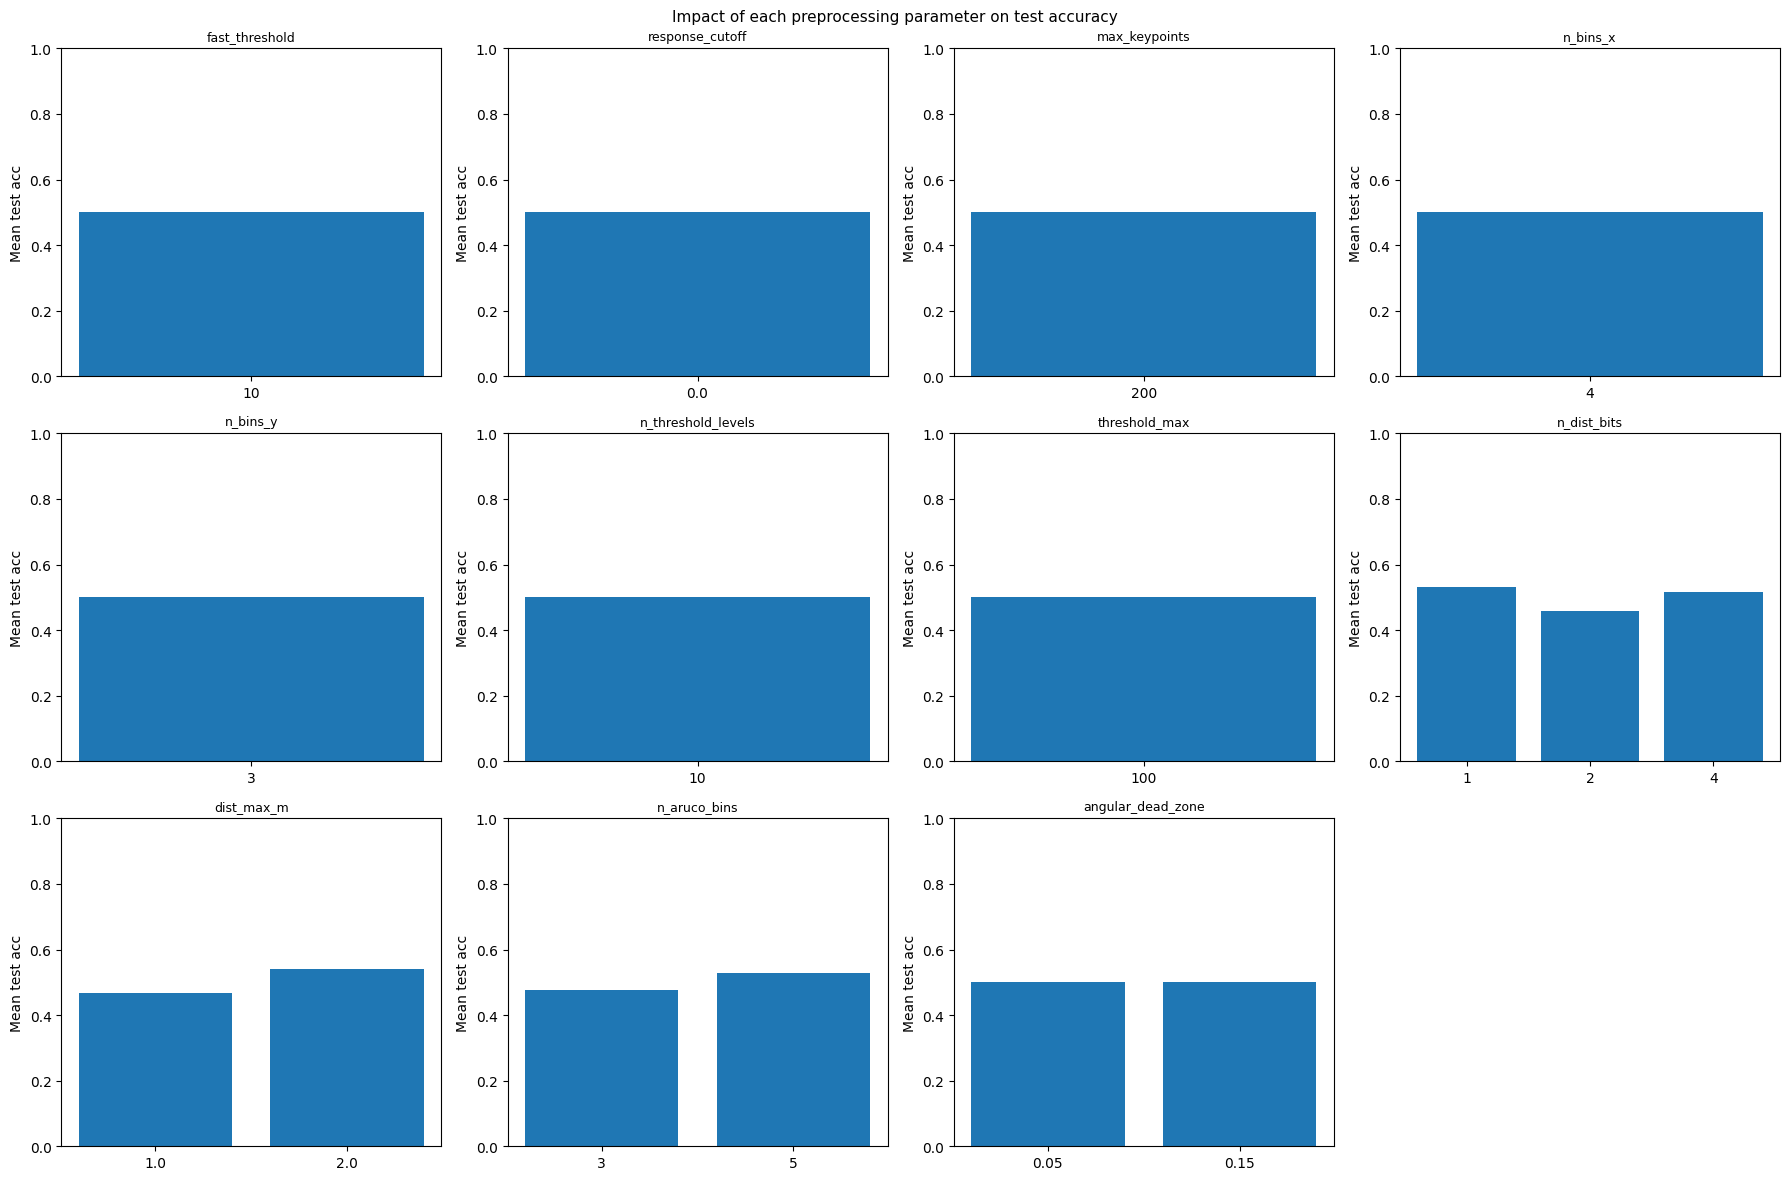

In [18]:
import matplotlib.pyplot as plt

tune_cols = preproc_cols[:-1]   # exclude n_inputs (derived)
n_cols    = 4
n_rows    = math.ceil(len(tune_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for ax, col in zip(axes, tune_cols):
    grouped = df.groupby(col)["mean_test_acc"].mean()
    ax.bar([str(v) for v in grouped.index], grouped.values)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("Mean test acc")
    ax.set_ylim(0, 1)

# Hide any unused subplots
for ax in axes[len(tune_cols):]:
    ax.set_visible(False)

plt.suptitle("Impact of each preprocessing parameter on test accuracy", fontsize=11)
plt.tight_layout()
plt.show()